In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from hydra import compose, initialize
from omegaconf import OmegaConf

from datasets import MultiMaze2dOfflineRLDataset
from algorithms.diffusion_forcing import DiffusionForcingPlanning

with initialize(version_base=None, config_path="configurations", job_name="debug"):
    cfg = compose(config_name="config")

dataset = MultiMaze2dOfflineRLDataset(cfg.dataset)
print(OmegaConf.to_yaml(cfg))
planner = DiffusionForcingPlanning(cfg.algorithm)

Generating Maze Dataset...
Generated 50 mazes with solutions up to length 17.
saved at {'training': 'data/multi_maze2d/training_mazes.npz', 'validation': 'data/multi_maze2d/validation_mazes.npz', 'test': 'data/multi_maze2d/test_mazes.npz'}
experiment:
  debug: ${debug}
  tasks:
  - training
  num_nodes: 1
  training:
    precision: 16-mixed
    compile: false
    lr: 0.0005
    batch_size: 512
    max_epochs: 1000
    max_steps: 50000
    max_time: null
    data:
      num_workers: 8
      shuffle: true
    optim:
      accumulate_grad_batches: 1
      gradient_clip_val: 0
    checkpointing:
      every_n_train_steps: 10000
      every_n_epochs: null
      train_time_interval: null
      enable_version_counter: false
  validation:
    precision: 32
    compile: false
    batch_size: 128
    val_every_n_step: null
    val_every_n_epoch: 10
    limit_batch: 1
    inference_mode: false
    data:
      num_workers: 16
      shuffle: false
  test:
    precision: 16-mixed
    compile: false


In [16]:
import torch
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=20,
    num_workers=1,
    shuffle=True,
    persistent_workers=True,
)
# maze, goal, positions, actions, rewards, nonterminals
batch = next(iter(data_loader))

maze torch.Size([5, 7, 7])
trajectory torch.Size([5, 33, 2]) torch.int32
start torch.Size([5, 2])
goal torch.Size([5, 2])


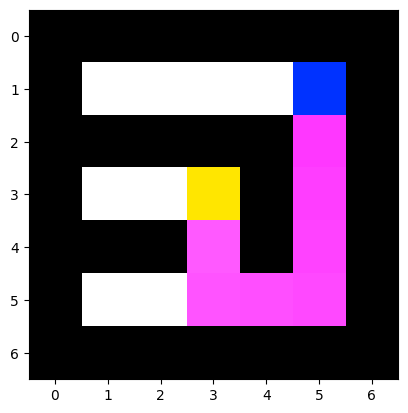

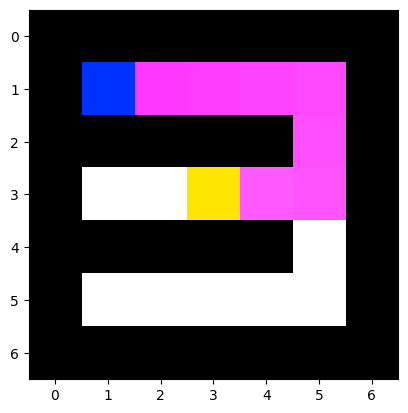

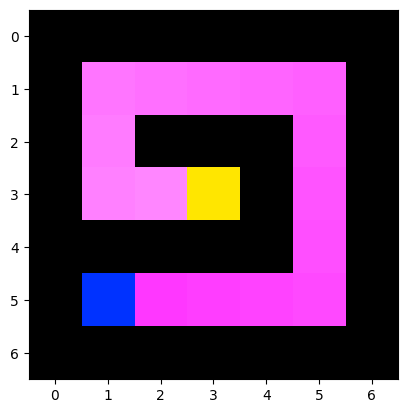

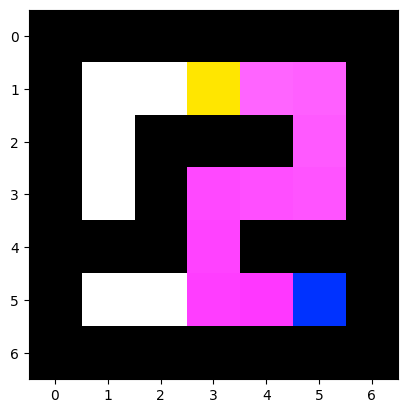

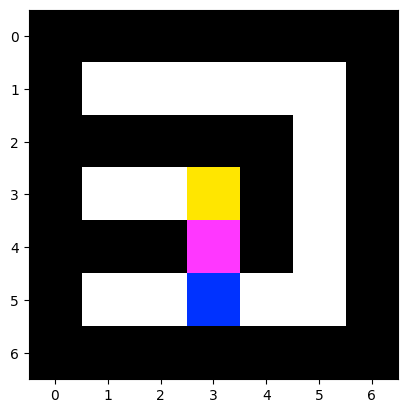

In [17]:
from utils.logging_utils import make_grid_images
import matplotlib.pyplot as plt
imgs = make_grid_images(batch, 5)
for img in imgs:
    plt.imshow(img)
    plt.show()

In [6]:
output_dict = planner.validation_step(batch, 1)

maze torch.Size([8, 7, 7])
trajectory torch.Size([8, 7, 2]) torch.int32
start torch.Size([8, 2])
goal torch.Size([8, 2])


AttributeError: 'NoneType' object has no attribute 'log_image'